In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
os.makedirs('random/models', exist_ok=True)

In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_rf_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Alcohol Consumption', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


------------------------------
Random Forest - Baseline (No Sampling)
------------------------------


Fold 1: Val Accuracy = 0.8000


Fold 2: Val Accuracy = 0.8000


Fold 3: Val Accuracy = 0.8000


Fold 4: Val Accuracy = 0.7994


Fold 5: Val Accuracy = 0.8000
------------------------------
>> Average CV Accuracy: 0.7999 (± 0.0002)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.8000)
------------------------------
Test Evaluation


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


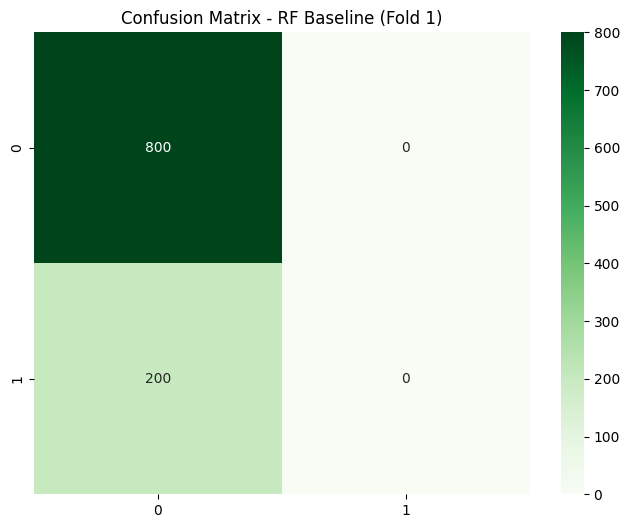

✓ Saved: random/models/RF_baseline_bestfold.pkl


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่า (RF - Baseline)
# ==========================================
print("-" * 30)
print('Random Forest - Baseline (No Sampling)')
print("-" * 30)

best_model_rf_base = None
best_score_rf_base = 0
best_fold_idx_rf_base = -1

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # สร้างโมเดล Random Forest
    # n_estimators=100 : ใช้ต้นไม้ 100 ต้น
    # n_jobs=-1 : ใช้ CPU ทุก Core ช่วยคำนวณ (เร็วขึ้น)
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_fold_train, y_fold_train)
    
    # Validate
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_rf_base:
        best_score_rf_base = score
        best_model_rf_base = model
        best_fold_idx_rf_base = fold
# Summary of CV
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_rf_base} (Score: {best_score_rf_base:.4f})')
print("-" * 30)
# ==========================================
# 📊 ส่วนที่ 3: Test Evaluation
# ==========================================
y_pred = best_model_rf_base.predict(X_test)
y_pred_proba = best_model_rf_base.predict_proba(X_test)[:, 1]

baseline_results = {
    'Model': 'Random Forest',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

print("Test Evaluation")

# Save Results
os.makedirs('random/models', exist_ok=True)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - RF Baseline (Fold {best_fold_idx_rf_base})')
plt.savefig('random/models/cm_rf_baseline.png', dpi=300)
plt.show()

joblib.dump(best_model_rf_base, 'random/models/RF_baseline_bestfold.pkl')
print(f"✓ Saved: random/models/RF_baseline_bestfold.pkl")

------------------------------
Random Forest + SMOTE (Pick Best Fold)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.7156


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.7172


...

Fold 3: Val Accuracy = 0.7083


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.7150


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.7161
------------------------------
>> Average CV Accuracy: 0.7144 (± 0.0031)
>> 🏆 Best Model Found in Fold: 2
------------------------------

TEST SET PERFORMANCE (SMOTE)
Accuracy:  0.7120
Precision: 0.1944
Recall:    0.1400
F1-Score:  0.1628
ROC-AUC:   0.4770

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.85      0.83       800
     Disease       0.19      0.14      0.16       200

    accuracy                           0.71      1000
   macro avg       0.50      0.50      0.49      1000
weighted avg       0.68      0.71      0.69      1000



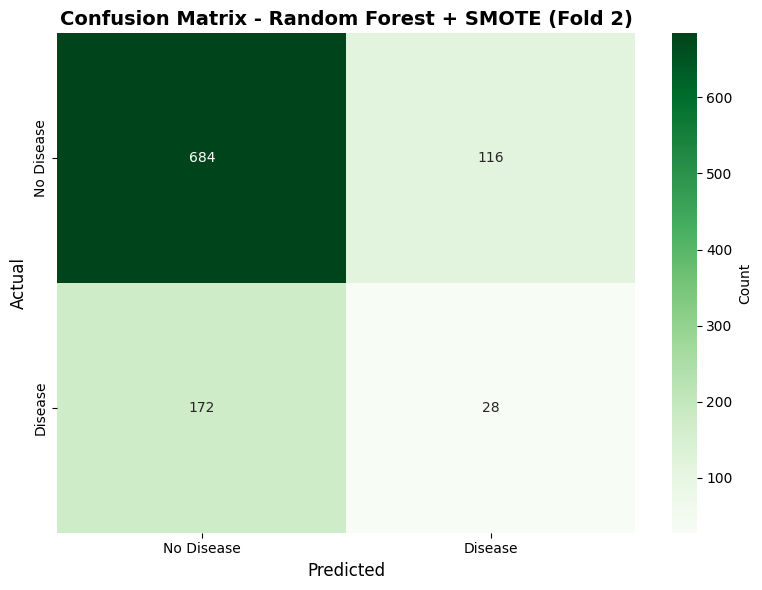

✓ Saved: random/models/Random_forest_smote_bestfold.pkl


In [4]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('Random Forest + SMOTE (Pick Best Fold)')
print("-" * 30)

best_model_rf_smote = None
best_score_rf_smote = 0
best_fold_idx_rf_smote = -1
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]

    smote = SMOTE(random_state=42)
    X_fold_train_res, y_fold_train_res = smote.fit_resample(X_fold_train, y_fold_train)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_fold_train_res, y_fold_train_res)

    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")

    if score > best_score_rf_smote:
        best_score_rf_smote = score
        best_model_rf_smote = model
        best_fold_idx_rf_smote = fold

print("-" * 30)

print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_rf_smote}')
print("-" * 30)

# Evaluate best model on test set
y_pred = best_model_rf_smote.predict(X_test)
y_pred_proba = best_model_rf_smote.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTE)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - Random Forest + SMOTE (Fold {best_fold_idx_rf_smote})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
rf_smote_results = {
    'Model': 'Random Forest',
    'Sampling': f'SMOTE (Fold {best_fold_idx_rf_smote})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save model and sampler
joblib.dump(best_model_rf_smote, 'random/models/Random_forest_smote_bestfold.pkl')
print("✓ Saved: random/models/Random_forest_smote_bestfold.pkl")

------------------------------
Random Forest + ADASYN (Pick Best Fold)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.7011


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.7128


...

Fold 3: Val Accuracy = 0.7056


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.7111


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.7150
------------------------------
>> Average CV Accuracy: 0.7091 (± 0.0051)
>> 🏆 Best Model Found in Fold: 5
------------------------------

TEST SET PERFORMANCE (ADASYN)
Accuracy:  0.6880
Precision: 0.1957
Recall:    0.1800
F1-Score:  0.1875
ROC-AUC:   0.4829

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.81      0.81       800
     Disease       0.20      0.18      0.19       200

    accuracy                           0.69      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.68      0.69      0.68      1000



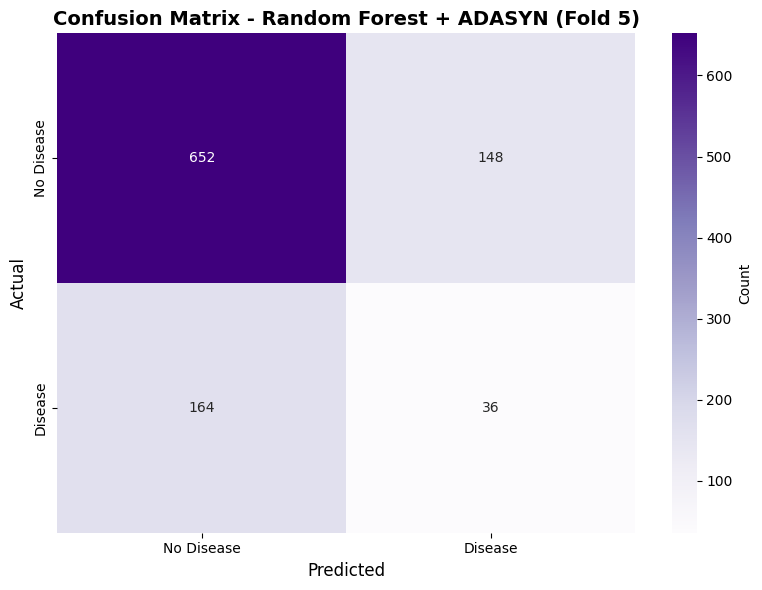

✓ Saved: random/models/Random_forest_adasyn_bestfold.pkl


In [5]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('Random Forest + ADASYN (Pick Best Fold)')
print("-" * 30)

best_model_rf_adasyn = None
best_score_rf_adasyn = 0
best_fold_idx_rf_adasyn = -1
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]

    ada = ADASYN(random_state=42, n_neighbors=5)
    try:
        X_fold_train_res, y_fold_train_res = ada.fit_resample(X_fold_train, y_fold_train)
    except ValueError as e:
        print(f"Warning in fold {fold}: {e}")
        continue

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_fold_train_res, y_fold_train_res)

    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")

    if score > best_score_rf_adasyn:
        best_score_rf_adasyn = score
        best_model_rf_adasyn = model
        best_fold_idx_rf_adasyn = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_rf_adasyn}')
print("-" * 30)

# Evaluate best model
y_pred = best_model_rf_adasyn.predict(X_test)
y_pred_proba = best_model_rf_adasyn.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - Random Forest + ADASYN (Fold {best_fold_idx_rf_adasyn})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
rf_adasyn_results = {
    'Model': 'Random Forest',
    'Sampling': f'ADASYN (Fold {best_fold_idx_rf_adasyn})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save best model
joblib.dump(best_model_rf_adasyn, 'random/models/Random_forest_adasyn_bestfold.pkl')
print("✓ Saved: random/models/Random_forest_adasyn_bestfold.pkl")

------------------------------
Random Forest + RandomUnderSampler (Pick Best Fold)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 1: Val Accuracy = 0.5028


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 2: Val Accuracy = 0.5056


...

Fold 3: Val Accuracy = 0.4694


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 4: Val Accuracy = 0.4989


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 5: Val Accuracy = 0.5128
------------------------------
>> Average CV Accuracy: 0.4979 (± 0.0149)
>> 🏆 Best Model Found in Fold: 5
------------------------------

TEST SET PERFORMANCE (RUS)
Accuracy:  0.4990
Precision: 0.1996
Recall:    0.5000
F1-Score:  0.2853
ROC-AUC:   0.4836

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.50      0.61       800
     Disease       0.20      0.50      0.29       200

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.45      1000
weighted avg       0.68      0.50      0.55      1000



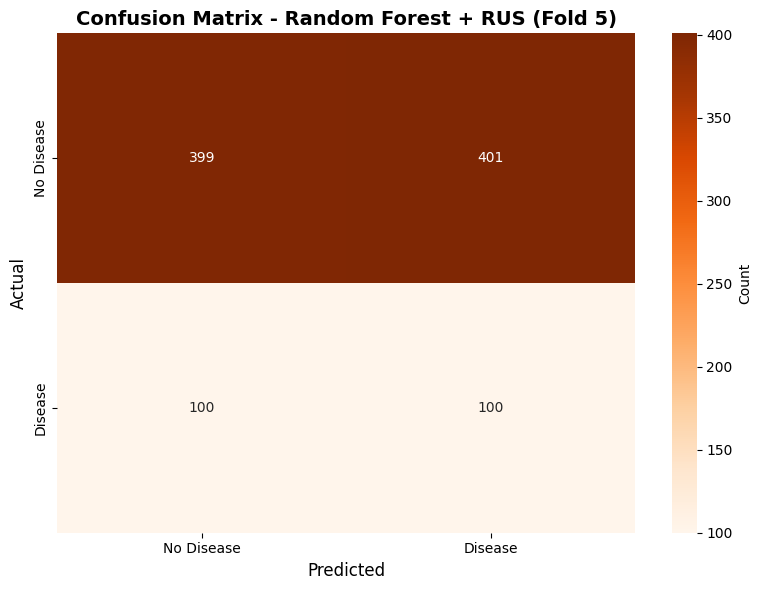

✓ Saved: random/models/Random_forest_rus_bestfold.pkl


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('Random Forest + RandomUnderSampler (Pick Best Fold)')
print("-" * 30)

best_model_rf_rus = None
best_score_rf_rus = 0
best_fold_idx_rf_rus = -1
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]

    rus = RandomUnderSampler(random_state=42)
    X_fold_train_res, y_fold_train_res = rus.fit_resample(X_fold_train, y_fold_train)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_fold_train_res, y_fold_train_res)

    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")

    if score > best_score_rf_rus:
        best_score_rf_rus = score
        best_model_rf_rus = model
        best_fold_idx_rf_rus = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_rf_rus}')
print("-" * 30)

# Evaluate best model
y_pred = best_model_rf_rus.predict(X_test)
y_pred_proba = best_model_rf_rus.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (RUS)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - Random Forest + RUS (Fold {best_fold_idx_rf_rus})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
rf_rus_results = {
    'Model': 'Random Forest',
    'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_rf_rus})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save best model
joblib.dump(best_model_rf_rus, 'random/models/Random_forest_rus_bestfold.pkl')
print("✓ Saved: random/models/Random_forest_rus_bestfold.pkl")

------------------------------
Random Forest + NearMiss (Pick Best Fold)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.3772


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.3589


...

Fold 3: Val Accuracy = 0.3561


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.3556


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.3672
------------------------------
>> Average CV Accuracy: 0.3630 (± 0.0082)
>> 🏆 Best Model Found in Fold: 1
------------------------------

TEST SET PERFORMANCE (NearMiss)
Accuracy:  0.3710
Precision: 0.2074
Recall:    0.7600
F1-Score:  0.3258
ROC-AUC:   0.5276

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.27      0.41       800
     Disease       0.21      0.76      0.33       200

    accuracy                           0.37      1000
   macro avg       0.51      0.52      0.37      1000
weighted avg       0.70      0.37      0.39      1000



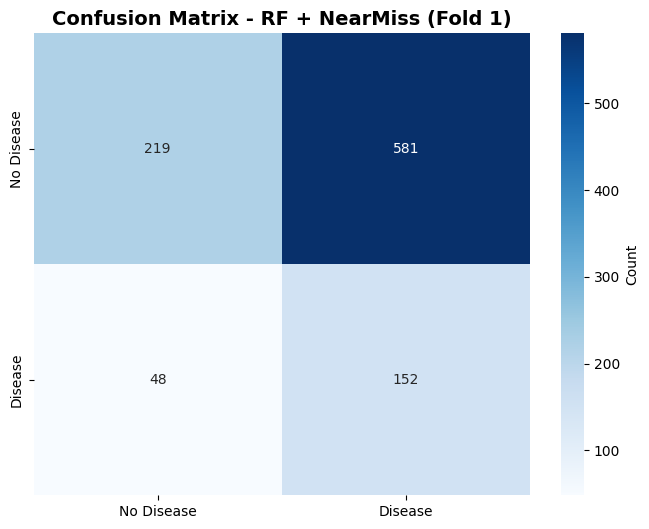

✓ Saved models: random/models/RF_nearmiss_bestfold.pkl


In [7]:
from imblearn.under_sampling import NearMiss
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib

print("-" * 30)
print('Random Forest + NearMiss (Pick Best Fold)')
print("-" * 30)

# Initialize NearMiss (version 2 is often effective)
nearmiss = NearMiss(version=2)

best_model_rf_nm = None
best_score_rf_nm = 0
best_fold_idx_rf_nm = -1
cv_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]

    nm = NearMiss(version=2)
    X_fold_train_res, y_fold_train_res = nm.fit_resample(X_fold_train, y_fold_train)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_fold_train_res, y_fold_train_res)

    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")

    if score > best_score_rf_nm:
        best_score_rf_nm = score
        best_model_rf_nm = model
        best_fold_idx_rf_nm = fold

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})")
print(f">> 🏆 Best Model Found in Fold: {best_fold_idx_rf_nm}")
print("-" * 30)

# Predictions using best model
y_pred = best_model_rf_nm.predict(X_test)
y_pred_proba = best_model_rf_nm.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (NearMiss)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - RF + NearMiss (Fold {best_fold_idx_rf_nm})', fontsize=14, fontweight='bold')
plt.show()

# Results Dictionary
rf_nearmiss_results = {
    'Model': 'Random Forest',
    'Sampling': f'NearMiss (Fold {best_fold_idx_rf_nm})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save Model and sampler
joblib.dump(best_model_rf_nm, 'random/models/RF_nearmiss_bestfold.pkl')
joblib.dump(nearmiss, 'random/models/nearmiss_sampler.pkl')
print("✓ Saved models: random/models/RF_nearmiss_bestfold.pkl")

------------------------------
Random Forest + Cluster Centroids
------------------------------
Resampling with Cluster Centroids... (This may take a while ⏳)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original training set size: 9000
After Cluster Centroids training set size: 3600
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After Cluster Centroids class distribution: {0: np.int64(1800), 1: np.int64(1800)}
------------------------------



------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------


Fold 1: 0.6889  (68.89%)


Fold 2: 0.6569  (65.69%)


Fold 3: 0.6917  (69.17%)


Fold 4: 0.6958  (69.58%)


Fold 5: 0.7042  (70.42%)
------------------------------
>> Average CV Accuracy: 0.6875 (± 0.0161)
------------------------------

TEST SET PERFORMANCE (Cluster Centroids)
Accuracy:  0.4130
Precision: 0.1933
Recall:    0.6100
F1-Score:  0.2936
ROC-AUC:   0.5104

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.36      0.50       800
     Disease       0.19      0.61      0.29       200

    accuracy                           0.41      1000
   macro avg       0.49      0.49      0.40      1000
weighted avg       0.67      0.41      0.46      1000



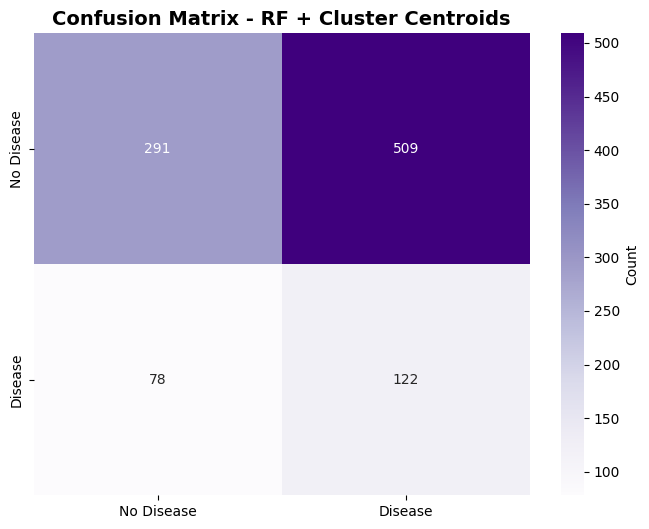

✓ Saved models: random/models/RF_cluster_centroids.pkl


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('Random Forest + Cluster Centroids')
print("-" * 30)

# Initialize Cluster Centroids
cc = ClusterCentroids(random_state=42, voting='soft')

# Apply Cluster Centroids
print("Resampling with Cluster Centroids... (This may take a while ⏳)")
X_train_cc, y_train_cc = cc.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After Cluster Centroids training set size: {len(X_train_cc)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After Cluster Centroids class distribution: {dict(pd.Series(y_train_cc).value_counts())}")
print("-" * 30)

# Initialize model
rf_cc = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_cc.fit(X_train_cc, y_train_cc)

# Cross-validation
print("\n" + "-" * 30)
print("Cross-Validation Scores (Total 5 Folds):")
print("-" * 30)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# ใช้ .iloc เพื่อป้องกัน KeyError
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cc, y_train_cc), 1):
    X_cv_train = X_train_cc.iloc[train_idx]
    X_cv_val = X_train_cc.iloc[val_idx]
    y_cv_train = y_train_cc[train_idx]
    y_cv_val = y_train_cc[val_idx]
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_temp.fit(X_cv_train, y_cv_train)
    score = rf_temp.score(X_cv_val, y_cv_val)
    cv_scores.append(score)
    print(f"Fold {fold}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})")
print("-" * 30)

# Predictions
y_pred = rf_cc.predict(X_test)
y_pred_proba = rf_cc.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Cluster Centroids)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - RF + Cluster Centroids', fontsize=14, fontweight='bold')
plt.show()

# Results Dictionary
rf_cc_results = {
    'Model': 'Random Forest',
    'Sampling': 'ClusterCentroids',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save Model
joblib.dump(rf_cc, 'random/models/RF_cluster_centroids.pkl')
joblib.dump(cc, 'random/models/cc_sampler.pkl')
print("✓ Saved models: random/models/RF_cluster_centroids.pkl")

------------------------------
Random Forest + SMOTETomek
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Original training set size: 9000
After SMOTETomek training set size: 14318
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTETomek class distribution: {0: np.int64(7159), 1: np.int64(7159)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7206  (72.06%)
Fold 2: 0.7211  (72.11%)
Fold 3: 0.7028  (70.28%)
Fold 4: 0.7139  (71.39%)
Fold 5: 0.7133  (71.33%)
------------------------------
>> Average CV Accuracy: 0.7143 (± 0.0066)
------------------------------



TEST SET PERFORMANCE (SMOTETomek)
Accuracy:  0.7050
Precision: 0.1724
Recall:    0.1250
F1-Score:  0.1449
ROC-AUC:   0.4664

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.85      0.82       800
     Disease       0.17      0.12      0.14       200

    accuracy                           0.70      1000
   macro avg       0.48      0.49      0.48      1000
weighted avg       0.67      0.70      0.69      1000



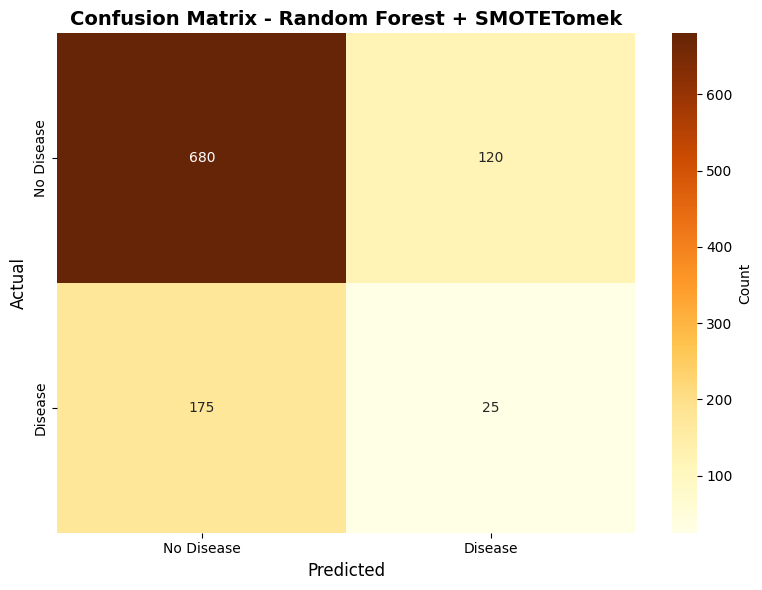


SMOTETomek RESULTS SUMMARY
Model               : Random Forest
Sampling            : SMOTETomek
CV_Accuracy         : 0.7143
CV_Std              : 0.0066
Test_Accuracy       : 0.7050
Precision           : 0.1724
Recall              : 0.1250
F1_Score            : 0.1449
ROC_AUC             : 0.4664
TP                  : 25
TN                  : 680
FP                  : 120
FN                  : 175
✓ Saved: random/models/Random_forest_smote_tomek.pkl
✓ Saved: random/models/smote_tomek_sampler_rf.pkl


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('Random Forest + SMOTETomek')
print("-" * 30)

# Initialize SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

# Apply SMOTETomek to training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTETomek training set size: {len(X_train_smote_tomek)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTETomek class distribution: {dict(pd.Series(y_train_smote_tomek).value_counts())}")
print("-" * 30)

# Initialize model
rf_model_smote_tomek = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in cv.split(X_train, y_train.values.ravel()):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    X_train_fold_smote_tomek, y_train_fold_smote_tomek = smote_tomek.fit_resample(X_train_fold, y_train_fold)
    rf_model_smote_tomek.fit(X_train_fold_smote_tomek, y_train_fold_smote_tomek)
    score = rf_model_smote_tomek.score(X_val_fold, y_val_fold)
    cv_scores.append(score)

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Train on full training set
rf_model_smote_tomek.fit(X_train_smote_tomek, y_train_smote_tomek)

# Predictions
y_pred = rf_model_smote_tomek.predict(X_test)
y_pred_proba = rf_model_smote_tomek.predict_proba(X_test)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTETomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Random Forest + SMOTETomek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
rf_smote_tomek_results = {
    'Model': 'Random Forest',
    'Sampling': 'SMOTETomek',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

print("\n" + "=" * 50)
print("SMOTETomek RESULTS SUMMARY")
print("=" * 50)
for key, value in rf_smote_tomek_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save model
joblib.dump(rf_model_smote_tomek, 'random/models/Random_forest_smote_tomek.pkl')
joblib.dump(smote_tomek, 'random/models/smote_tomek_sampler_rf.pkl')
print("✓ Saved: random/models/Random_forest_smote_tomek.pkl")
print("✓ Saved: random/models/smote_tomek_sampler_rf.pkl")

------------------------------
Random Forest + SMOTEENN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Original training set size: 9000
After SMOTEENN training set size: 9187
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTEENN class distribution: {1: np.int64(6454), 0: np.int64(2733)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.4817  (48.17%)
Fold 2: 0.4900  (49.00%)
Fold 3: 0.4678  (46.78%)
Fold 4: 0.4683  (46.83%)
Fold 5: 0.4839  (48.39%)
------------------------------
>> Average CV Accuracy: 0.4783 (± 0.0088)
------------------------------



TEST SET PERFORMANCE (SMOTEENN)
Accuracy:  0.4560
Precision: 0.1940
Recall:    0.5450
F1-Score:  0.2861
ROC-AUC:   0.4704

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.43      0.56       800
     Disease       0.19      0.55      0.29       200

    accuracy                           0.46      1000
   macro avg       0.49      0.49      0.42      1000
weighted avg       0.67      0.46      0.51      1000



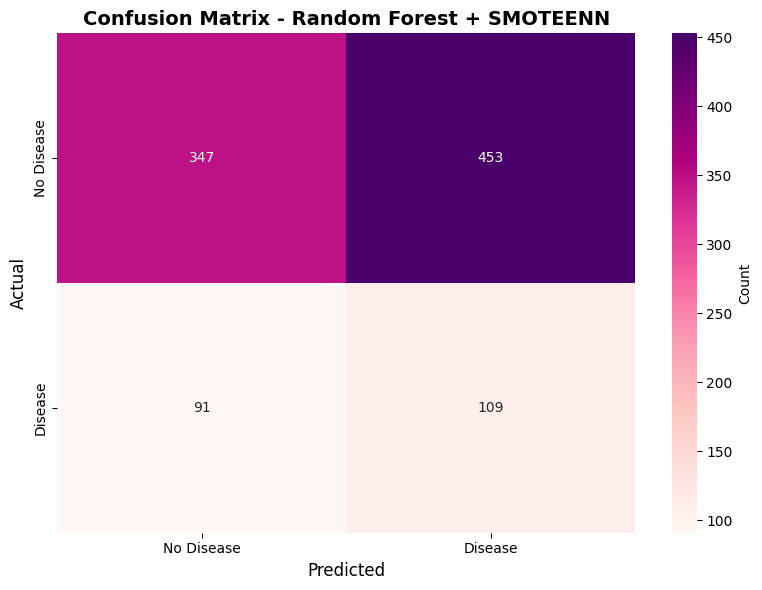


SMOTEENN RESULTS SUMMARY
Model               : Random Forest
Sampling            : SMOTEENN
CV_Accuracy         : 0.4783
CV_Std              : 0.0088
Test_Accuracy       : 0.4560
Precision           : 0.1940
Recall              : 0.5450
F1_Score            : 0.2861
ROC_AUC             : 0.4704
TP                  : 109
TN                  : 347
FP                  : 453
FN                  : 91
✓ Saved: random/models/Random_forest_smote_enn.pkl
✓ Saved: random/models/smote_enn_sampler_rf.pkl


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('Random Forest + SMOTEENN')
print("-" * 30)

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN to training data
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTEENN training set size: {len(X_train_smote_enn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTEENN class distribution: {dict(pd.Series(y_train_smote_enn).value_counts())}")
print("-" * 30)

# Initialize model
rf_model_smote_enn = RandomForestClassifier(n_estimators=100, random_state=42)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in cv.split(X_train, y_train.values.ravel()):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    X_train_fold_smote_enn, y_train_fold_smote_enn = smote_enn.fit_resample(X_train_fold, y_train_fold)
    rf_model_smote_enn.fit(X_train_fold_smote_enn, y_train_fold_smote_enn)
    score = rf_model_smote_enn.score(X_val_fold, y_val_fold)
    cv_scores.append(score)

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Train on full training set
rf_model_smote_enn.fit(X_train_smote_enn, y_train_smote_enn)

# Predictions
y_pred = rf_model_smote_enn.predict(X_test)
y_pred_proba = rf_model_smote_enn.predict_proba(X_test)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTEENN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Random Forest + SMOTEENN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
rf_smote_enn_results = {
    'Model': 'Random Forest',
    'Sampling': 'SMOTEENN',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

print("\n" + "=" * 50)
print("SMOTEENN RESULTS SUMMARY")
print("=" * 50)
for key, value in rf_smote_enn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save model
joblib.dump(rf_model_smote_enn, 'random/models/Random_forest_smote_enn.pkl')
joblib.dump(smote_enn, 'random/models/smote_enn_sampler_rf.pkl')
print("✓ Saved: random/models/Random_forest_smote_enn.pkl")
print("✓ Saved: random/models/smote_enn_sampler_rf.pkl")

------------------------------
Random Forest + ADASYN + Tomek Links
------------------------------
Resampling with ADASYN + Tomek Links...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original training set size: 9000
After ADASYN+Tomek training set size: 14434
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After ADASYN+Tomek class distribution: {1: np.int64(7234), 0: np.int64(7200)}
------------------------------



------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------


Fold 1: 0.8344  (83.44%)


Fold 2: 0.8247  (82.47%)


Fold 3: 0.8341  (83.41%)


Fold 4: 0.8545  (85.45%)


Fold 5: 0.8382  (83.82%)
------------------------------
>> Average CV Accuracy: 0.8372 (± 0.0097)
------------------------------

TEST SET PERFORMANCE (ADASYN + Tomek)
Accuracy:  0.6940
Precision: 0.1768
Recall:    0.1450
F1-Score:  0.1593
ROC-AUC:   0.4824

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.83      0.81       800
     Disease       0.18      0.14      0.16       200

    accuracy                           0.69      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.67      0.69      0.68      1000



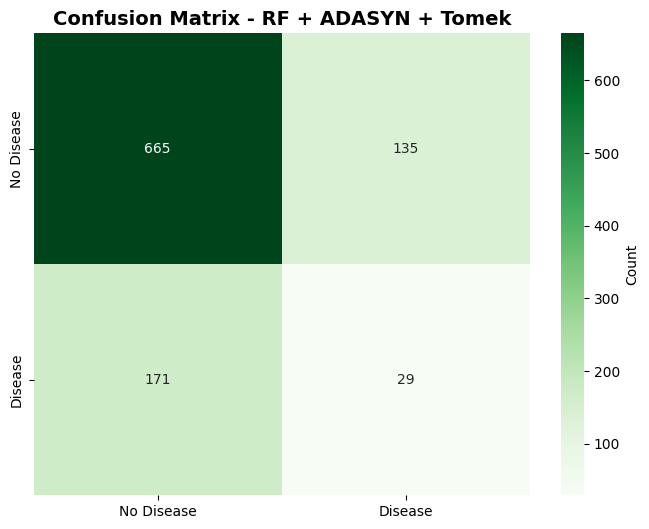

✓ Saved models: random/models/RF_adasyn_tomek.pkl


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('Random Forest + ADASYN + Tomek Links')
print("-" * 30)

# Create Pipeline
pipeline_at = ImbPipeline([
    ('adasyn', ADASYN(random_state=42, n_neighbors=5)),
    ('tomek', TomekLinks())
])

# Apply Resampling
print("Resampling with ADASYN + Tomek Links...")
X_train_at, y_train_at = pipeline_at.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After ADASYN+Tomek training set size: {len(X_train_at)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After ADASYN+Tomek class distribution: {dict(pd.Series(y_train_at).value_counts())}")
print("-" * 30)

# Initialize model
rf_at = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_at.fit(X_train_at, y_train_at)

# Cross-validation
print("\n" + "-" * 30)
print("Cross-Validation Scores (Total 5 Folds):")
print("-" * 30)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_at, y_train_at), 1):
    X_cv_train = X_train_at.iloc[train_idx]
    X_cv_val = X_train_at.iloc[val_idx]
    y_cv_train = y_train_at[train_idx]
    y_cv_val = y_train_at[val_idx]
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_temp.fit(X_cv_train, y_cv_train)
    score = rf_temp.score(X_cv_val, y_cv_val)
    cv_scores.append(score)
    print(f"Fold {fold}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})")
print("-" * 30)

# Predictions
y_pred = rf_at.predict(X_test)
y_pred_proba = rf_at.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN + Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - RF + ADASYN + Tomek', fontsize=14, fontweight='bold')
plt.show()

# Results Dictionary
rf_adasyn_tomek_results = {
    'Model': 'Random Forest',
    'Sampling': 'ADASYN+Tomek',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save Model
joblib.dump(rf_at, 'random/models/RF_adasyn_tomek.pkl')
joblib.dump(pipeline_at, 'random/models/adasyn_tomek_sampler.pkl')
print("✓ Saved models: random/models/RF_adasyn_tomek.pkl")

------------------------------
Random Forest + BorderlineSMOTE + Tomek Links
------------------------------
Resampling with BorderlineSMOTE + Tomek Links...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original training set size: 9000
After Borderline+Tomek training set size: 14285
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After Borderline+Tomek class distribution: {0: np.int64(7200), 1: np.int64(7085)}
------------------------------



------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------


Fold 1: 0.9149  (91.49%)


Fold 2: 0.9198  (91.98%)


Fold 3: 0.9002  (90.02%)


Fold 4: 0.9240  (92.40%)


Fold 5: 0.9135  (91.35%)
------------------------------
>> Average CV Accuracy: 0.9145 (± 0.0081)
------------------------------

TEST SET PERFORMANCE (Borderline+Tomek)
Accuracy:  0.7660
Precision: 0.1731
Recall:    0.0450
F1-Score:  0.0714
ROC-AUC:   0.4857

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.95      0.87       800
     Disease       0.17      0.04      0.07       200

    accuracy                           0.77      1000
   macro avg       0.49      0.50      0.47      1000
weighted avg       0.67      0.77      0.71      1000



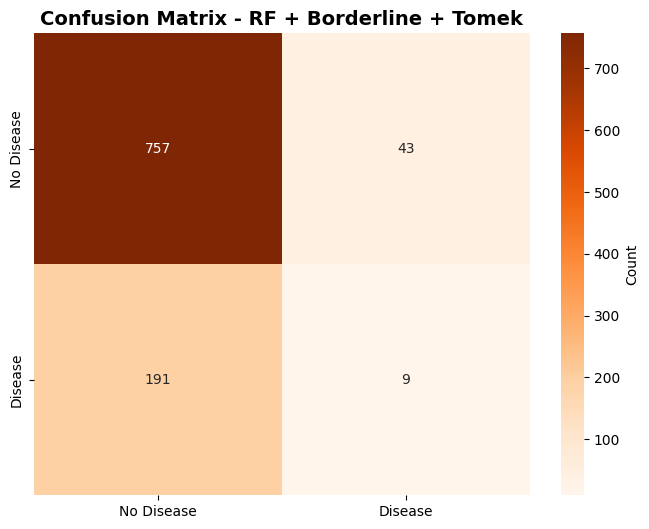

✓ Saved models: random/models/RF_borderline_tomek.pkl


In [12]:
from imblearn.over_sampling import BorderlineSMOTE

print("-" * 30)
print('Random Forest + BorderlineSMOTE + Tomek Links')
print("-" * 30)

# Create Pipeline
pipeline_bt = ImbPipeline([
    ('borderline', BorderlineSMOTE(random_state=42, kind='borderline-2')),
    ('tomek', TomekLinks())
])

# Apply Resampling
print("Resampling with BorderlineSMOTE + Tomek Links...")
X_train_bt, y_train_bt = pipeline_bt.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After Borderline+Tomek training set size: {len(X_train_bt)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After Borderline+Tomek class distribution: {dict(pd.Series(y_train_bt).value_counts())}")
print("-" * 30)

# Initialize model
rf_bt = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_bt.fit(X_train_bt, y_train_bt)

# Cross-validation
print("\n" + "-" * 30)
print("Cross-Validation Scores (Total 5 Folds):")
print("-" * 30)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_bt, y_train_bt), 1):
    X_cv_train = X_train_bt.iloc[train_idx]
    X_cv_val = X_train_bt.iloc[val_idx]
    y_cv_train = y_train_bt[train_idx]
    y_cv_val = y_train_bt[val_idx]
    
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_temp.fit(X_cv_train, y_cv_train)
    score = rf_temp.score(X_cv_val, y_cv_val)
    cv_scores.append(score)
    print(f"Fold {fold}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})")
print("-" * 30)

# Predictions
y_pred = rf_bt.predict(X_test)
y_pred_proba = rf_bt.predict_proba(X_test)[:, 1]

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Borderline+Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - RF + Borderline + Tomek', fontsize=14, fontweight='bold')
plt.show()

# Results Dictionary
rf_borderline_tomek_results = {
    'Model': 'Random Forest',
    'Sampling': 'BorderlineSMOTE+Tomek',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save Model
joblib.dump(rf_bt, 'random/models/RF_borderline_tomek.pkl')
joblib.dump(pipeline_bt, 'random/models/borderline_tomek_sampler.pkl')
print("✓ Saved models: random/models/RF_borderline_tomek.pkl")


RANDOM FOREST - COMPREHENSIVE SUMMARY


        Model                    Sampling  CV_Accuracy   CV_Std  Test_Accuracy  Precision  Recall  F1_Score  ROC_AUC  TP  TN  FP  FN
Random Forest             None (Baseline)     0.799889 0.000222          0.800   0.000000   0.000  0.000000 0.522475   0 800   0 200
Random Forest              SMOTE (Fold 2)     0.714444 0.003143          0.712   0.194444   0.140  0.162791 0.477016  28 684 116 172
Random Forest             ADASYN (Fold 5)     0.709111 0.005075          0.688   0.195652   0.180  0.187500 0.482931  36 652 148 164
Random Forest RandomUnderSampler (Fold 5)     0.497889 0.014929          0.499   0.199601   0.500  0.285307 0.483600 100 399 401 100
Random Forest                  SMOTETomek     0.714333 0.006624          0.705   0.172414   0.125  0.144928 0.466416  25 680 120 175
Random Forest                    SMOTEENN     0.478333 0.008826          0.456   0.193950   0.545  0.286089 0.470381 109 347 453  91
Random Forest           NearMiss (Fold 1)     0.363000 0.008245      

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14456/1570050194.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rf_comparison_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14456/1570050194.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rf_comparison_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14456/1570050194.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rf_comparison_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14456/1570050194.py:33: UserWarning: set_ticklabels() should only be used with a

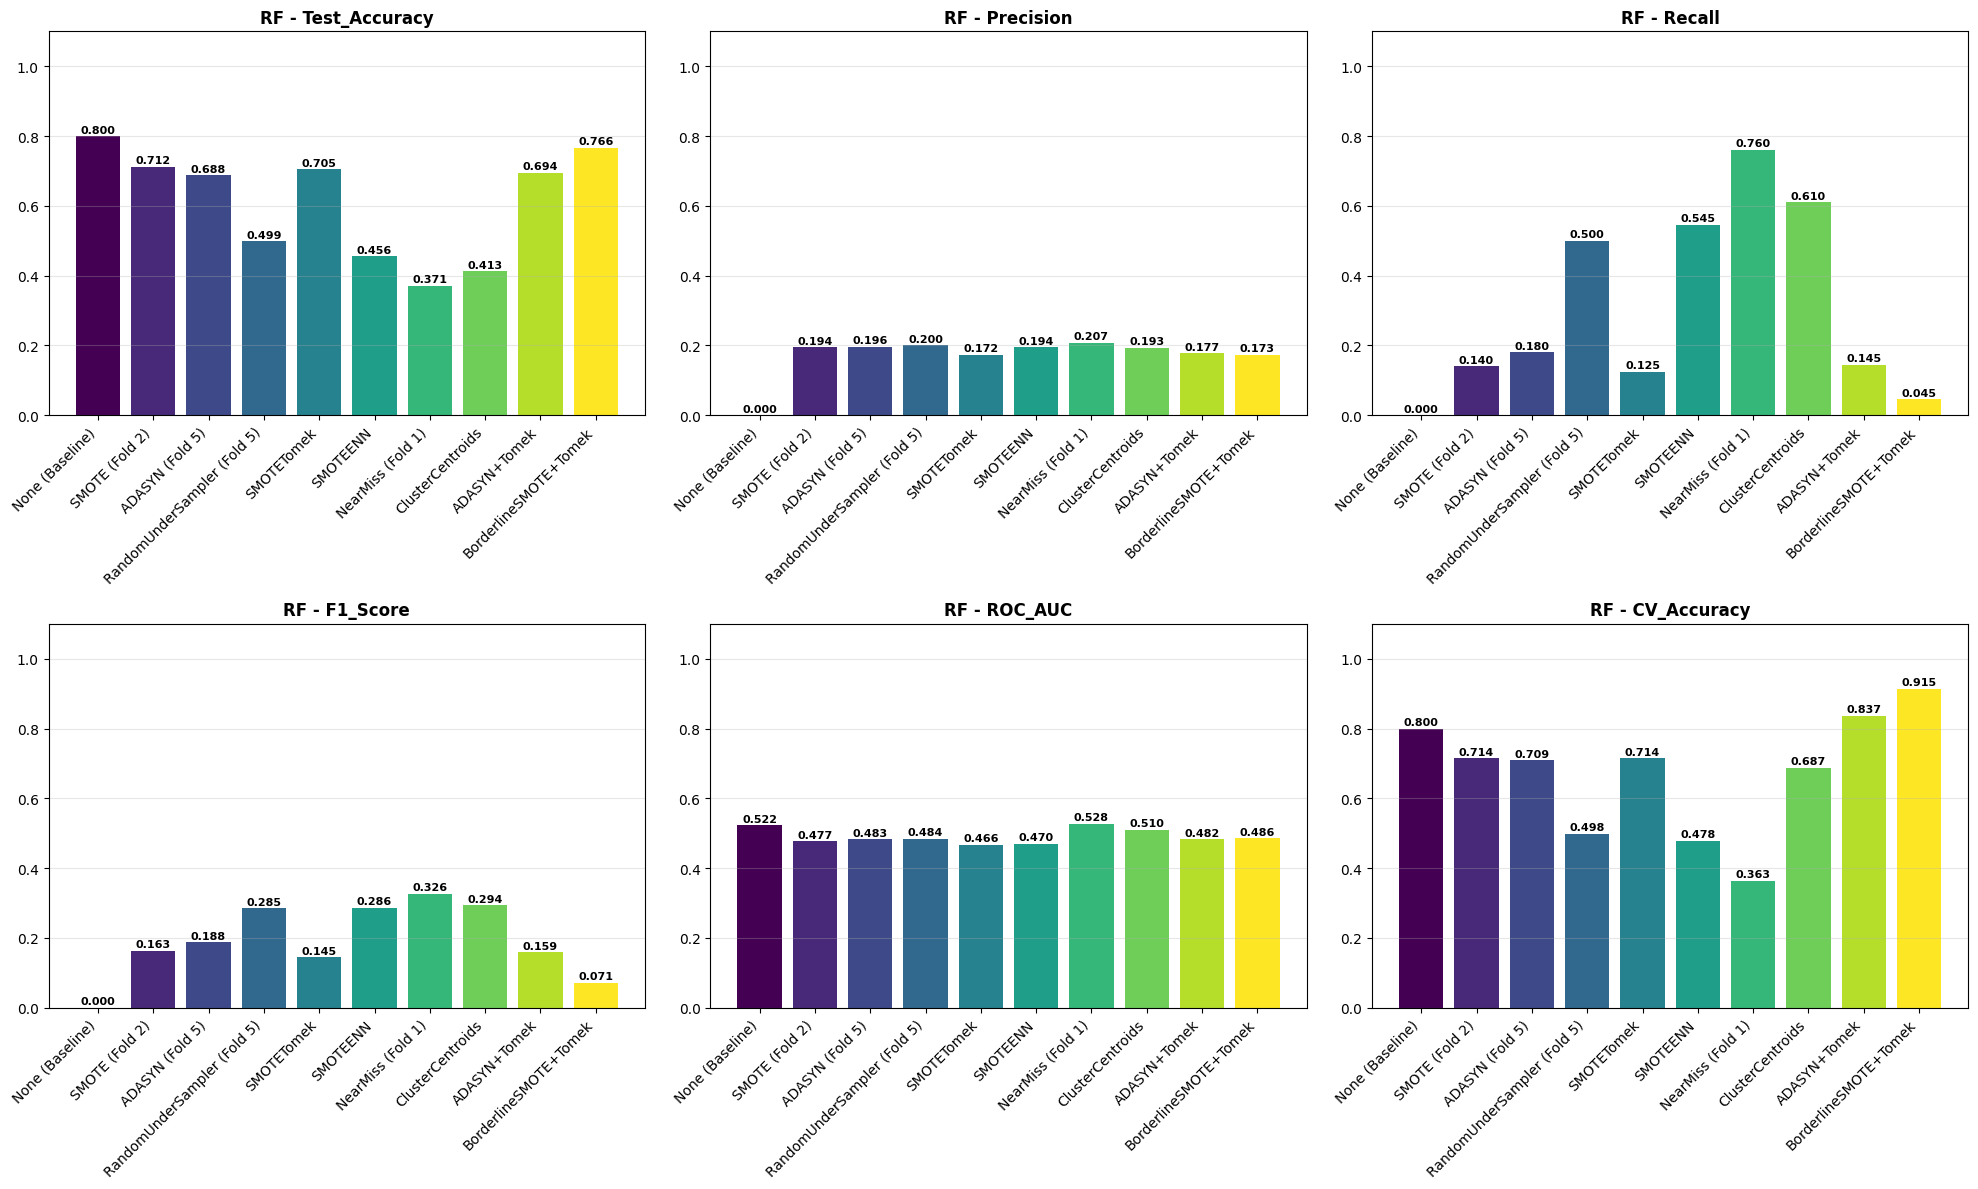

✓ Saved summary CSV


In [13]:
# รวมผลลัพธ์ทั้งหมด
rf_all_results = [
    baseline_results, 
    rf_smote_results, 
    rf_adasyn_results, 
    rf_rus_results, 
    rf_smote_tomek_results, 
    rf_smote_enn_results, 
    # ตัวใหม่
    rf_nearmiss_results, 
    rf_cc_results, 
    rf_adasyn_tomek_results, 
    rf_borderline_tomek_results
]

rf_comparison_df = pd.DataFrame(rf_all_results)

print("\n" + "=" * 90)
print("RANDOM FOREST - COMPREHENSIVE SUMMARY")
print("=" * 90)
print(rf_comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Accuracy']
colors = plt.cm.viridis(np.linspace(0, 1, len(rf_comparison_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(rf_comparison_df['Sampling'], rf_comparison_df[metric], color=colors)
    ax.set_title(f'RF - {metric}', fontsize=12, fontweight='bold')
    ax.set_xticklabels(rf_comparison_df['Sampling'], rotation=45, ha='right')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('random/models/rf_comparison_plot.png', dpi=300)
plt.show()

# Save CSV
rf_comparison_df.to_csv('random/models/rf_summary.csv', index=False)
print("✓ Saved summary CSV")